In [5]:
!pip install opendatasets --quiet

import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/animal-faces


100%|██████████| 696M/696M [02:41<00:00, 4.53MB/s] 


In [27]:
import torch
import torch.nn as nn
from torch.optim import Adam
import torchvision.transforms as transforms

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device is:", device)

Device is: cpu


# Reading Data Paths 

The following code will be going through a nested directory structure where images are stored within subdirectories,each directory is representing a specific label (category). It constructs a list of the file paths for these images and their corresponding labels. Then , it creates a pandas DataFrame contraining this information, which is useful for further data processing. Keep in mind that we will read all the data and then we will split it again to train, validation and testing. 

In [28]:
import os
print(os.listdir("animal-faces"))

['afhq']


In [29]:
image_path = [] # Empty array where we will fill the paths of the images
labels = [] # Empty array where we will fill the labels of the images

for i in os.listdir("animal-faces/afhq/"): # Looping through train and val folders
    for label in os.listdir(f"animal-faces/afhq/{i}"): # Looping through cat, dog, wild folders
        for image in os.listdir(f"animal-faces/afhq/{i}/{label}"): # Looping through all images

            labels.append(label) # Store label
            image_path.append(f"animal-faces/afhq/{i}/{label}/{image}") # Store image path

data_df = pd.DataFrame(
    zip(image_path, labels),
    columns=['image_paths', 'labels']
    # Create a dataframe contains the images paths and the labels 
)

data_df.head()

,image_paths,labels
0,animal-faces/afhq/train/cat/pixabay_cat_000455...,cat
1,animal-faces/afhq/train/cat/pixabay_cat_001993...,cat
2,animal-faces/afhq/train/cat/pixabay_cat_004633...,cat
3,animal-faces/afhq/train/cat/pixabay_cat_002242...,cat
4,animal-faces/afhq/train/cat/pixabay_cat_002524...,cat


In [30]:
train=data_df.sample(frac=0.7,random_state=42) # Create training of 70% of the data
# we want to be able to reproduce the same results every time we run the code,
#  setting a random state ensures that the same random numbers are generated each time, 
# which allows us to get the same training and testing splits of the data.

# The choice of 42 as the random state is arbitrary and does not have any specific significance. 
# It is simply a commonly used value for the random state in machine learning experiments.
test=data_df.drop(train.index)

val = test.sample(frac=0.5,random_state=42) # Create validation of 15% of the data
test = test.drop(val.index) # Create testing by removing the validation data from the test data


In [31]:
label_encoder = LabelEncoder() # Create a label encoder to encode the labels into numerical values
label_encoder.fit(data_df['labels']) # Fit the label encoder on the labels of the dataframe

transform = transforms.Compose([
    transforms.Resize((128,128)), # One size for all the images
    transforms.ToTensor(), # Convert the image to a tensor
    transforms.ConvertImageDtype(torch.float) # Transform the image to a float tensor (values between 0 and 1)
])
# Tranform all images into one clear format (preprocess all images to same properties)


In [32]:
class CustomImageDataset(Dataset):
    def __init__(self, dataframe,transform=None):
        self.dataframe = dataframe
        # Store the dataframe containing the image paths and labels
        self.transform = transform
        # Store the transform function to be applied to the images
        self.labels = torch.tensor(label_encoder.transform(dataframe['labels'])).to(device)
        # Encode the labels using the label encoder and convert them to a tensor on the specified device (CPU or GPU) or mps (Apple Silicon)

    def __len__(self):
        return self.dataframe.shape[0]
    
    def __getitem__(self,idx):
        img_path = self.dataframe.iloc[idx,0] # Get the image path at the specified index
        label = self.labels[idx] # Get the corresponding label for the image
        image = Image.open(img_path).convert("RGB") # Open the image and convert it to RGB format
        if self.transform: 
            image = self.transform(image) # Apply the specified transformations to the image
        return image, label # Return the transformed image and its corresponding label as a tuple

In [33]:
train_dataset = CustomImageDataset(dataframe=train,transform=transform)
val_dataset = CustomImageDataset(dataframe=val,transform=transform)
test_dataset = CustomImageDataset(dataframe=test,transform=transform)

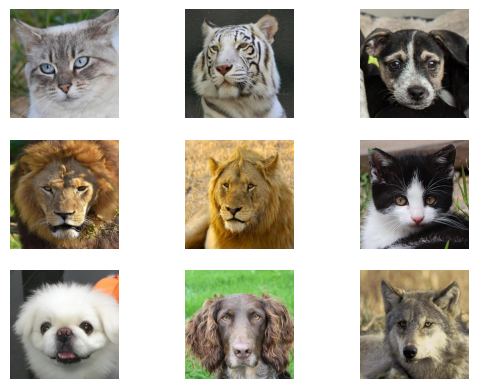

In [34]:
n_rows = 3
n_cols = 3

f,axarr = plt.subplots(n_rows,n_cols)
for row in range(n_rows):
    for col in range(n_cols):
        image = Image.open(data_df.sample(n=1)['image_paths'].iloc[0]).convert("RGB")
        # Sample a random image from the dataframe, open it, and convert it to RGB format.
        # RGB stands for Red, Green, Blue.
        #  It is a color model used in digital imaging
        #  and displays. In the RGB color model, colors 
        # are represented as combinations of red, green, 
        # and blue light. Each color channel (red, green, and blue)
        #  can have a value ranging from 0 to 255, where 0 represents 
        # no intensity and 255 represents full intensity.
        axarr[row,col].imshow(image)
        # Display the image in the corresponding subplot
        axarr[row,col].axis('off')
        # Hide the axes for the subplot
plt.show()

In [44]:
LR = 1e-4 # Set the learning rate for training the model.
BATCH_SIZE = 16 # Set the batch size for training the model. 
#The batch size determines how many samples will be processed before the model's 
# internal parameters are updated. A smaller batch size can lead to more 
# frequent updates and potentially faster convergence, while a larger batch 
# size can provide more stable updates but may require more memory and computational resources.
#  The choice of batch size can depend on factors such as the size of the dataset,
#  available hardware, and the specific requirements of the model being trained.

EPOCHS = 10 # Set the number of epochs for training the model. 
# An epoch is one complete pass through the entire training dataset. elaborate more on this
# During each epoch, the model is trained on the training data and then evaluated on the 
# validation data. The number of epochs determines how many times the model will see the 
# entire training dataset during the training process. A higher number of epochs can allow 
# the model to learn more complex patterns in the data, but it can also lead to overfitting 
# if the model starts to memorize the training data instead of generalizing to unseen data. 
# The choice of the number of epochs can depend on factors such as the size of the dataset, 
# the complexity of the model, and the desired level of performance. It is common to monitor 
# the model's performance on the validation set during training and use techniques such as 
# early stopping to prevent overfitting if the validation performance starts to degrade.

In [45]:
train_loader = DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=BATCH_SIZE,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=True)

In [46]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3,32,kernel_size=3,padding=1)
        # The first convolutional layer takes an input with 3 channels (RGB image) 
        # and produces an output with 32 channels.
        # The kernel size of 3 means that the convolutional filter will have a size of 3x3,
        #  and the padding of 1 means that the input will be padded with a 1-pixel border of
        #  zeros around the edges to maintain the spatial dimensions of the output.


        # Conv2d is a convolutional layer in PyTorch that applies a 2D convolution operation to the input data. 
        # It takes an input tensor of shape (batch_size, in_channels, height, width) and produces an output tensor of shape (batch_size, out_channels, height, width). 
        # The convolution operation involves sliding a filter (or kernel) across the input data and computing the dot product between the filter and the input at each position.


        # Convolution is a mathematical operation that combines two functions to produce a third function.
        # In the context of image processing and deep learning, convolution is used to extract features from images. 
        # It involves applying a filter (or kernel) to an input image to produce a feature map. The filter is a small matrix of weights that is learned during the training process.
        # The convolution operation involves sliding the filter across the input image and computing the dot product between

        self.conv2 = nn.Conv2d(32,64,kernel_size=3,padding=1)
        self.conv3 = nn.Conv2d(64,128,kernel_size=3,padding=1)
        # We are increasing the number of channels in each layer, which allows the model to learn more complex features from the input data.
        self.pooling = nn.MaxPool2d(2,2)
        # MaxPool2d is a pooling layer in PyTorch that applies a 2D max pooling operation to the input data.
        # It takes an input tensor of shape (batch_size, in_channels, height, width) and produces an output tensor of shape (batch_size, in_channels, height/2, width/2). 
        # The max pooling operation involves sliding a window (or kernel) across the input data and taking the maximum value within each window. 
        # The kernel size of 2 means that the pooling window will have a size of 2x2, and the stride of 2 means that the window will move 2 pixels at a time, effectively reducing the spatial dimensions of the output by a factor of 2.
        self.relu = nn.ReLU()

        self.flatten = nn.Flatten() # The flatten layer is used to reshape the output of the convolutional layers into a 1D vector, which can then be fed into the fully connected layers.
        self.linear = nn.Linear((128*16*16),128) # Traditional Dense layer that takes the flattened output from the convolutional layers and produces an output of size 128.
        self.output = nn.Linear(128,len(data_df['labels'].unique()))
        # Output Linear Layer

    def forward(self,x):
        x = self.conv1(x) # -> Outputs: (32,128,128)
        x = self.pooling(x) # -> Outputs: (32,64,64)
        x = self.relu(x)
        x = self.conv2(x) # -> Outputs: (64,64,64)
        x = self.pooling(x) # -> Outputs : (64,32,32)
        x = self.relu(x)
        x = self.conv3(x) # -> Outputs: (128,32,32)
        x = self.pooling(x) # -> Outputs: (128,16,16)
        x = self.relu(x)
        x = self.flatten(x)
        x = self.linear(x)
        x = self.output(x)

        return x
    
model = Net().to(device) # Create an instance of the model and move it to the GPU Device

        

## Understanding `nn.Linear(128 * 16 * 16, 128)`

### The Key Question

Why do we use:

```python
self.linear = nn.Linear(128 * 16 * 16, 128)
```

To understand this, we need to trace how the image dimensions change as they pass through the convolutional and pooling layers.

---

## Input Image

Assume the images are resized to:

```python
transforms.Resize((128, 128))
```

Each image starts with the shape:

```text
3 × 128 × 128
```

Where:

- **3** = RGB channels
- **128** = Height
- **128** = Width

---

## After Convolution Layer 1

```python
self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
```

Since:

- `kernel_size = 3`
- `padding = 1`

the spatial dimensions remain unchanged.

### Output Shape

```text
32 × 128 × 128
```

The number of channels increases from **3** to **32**.

---

## After First Max Pooling Layer

```python
self.pooling = nn.MaxPool2d(2, 2)
```

Max pooling reduces the height and width by half.

### Transformation

```text
128 → 64
128 → 64
```

### Output Shape

```text
32 × 64 × 64
```

---

## After Convolution Layer 2

```python
self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
```

### Output Shape

```text
64 × 64 × 64
```

---

## After Second Max Pooling Layer

### Transformation

```text
64 → 32
64 → 32
```

### Output Shape

```text
64 × 32 × 32
```

---

## After Convolution Layer 3

```python
self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
```

### Output Shape

```text
128 × 32 × 32
```

---

## After Third Max Pooling Layer

### Transformation

```text
32 → 16
32 → 16
```

### Output Shape

```text
128 × 16 × 16
```

---

## Why Do We Use Flatten?

At this stage, the tensor has the shape:

```text
(batch_size, 128, 16, 16)
```

However, a fully connected (`Linear`) layer expects a 1-dimensional input vector.

Therefore, we use:

```python
self.flatten = nn.Flatten()
```

which converts:

```text
128 × 16 × 16
```

into:

```text
32768
```

because:

```text
128 × 16 × 16 = 32768
```

---

## Therefore

The first fully connected layer must accept **32768 input features**.

This is why we write:

```python
self.linear = nn.Linear(128 * 16 * 16, 128)
```

which is equivalent to:

```python
self.linear = nn.Linear(32768, 128)
```

This layer takes the 32,768 extracted features and reduces them to 128 features that can be used for classification.

---

## Complete Shape Flow Through the Network

```text
Input Image
3 × 128 × 128
        │
        ▼
Conv1
32 × 128 × 128
        │
        ▼
MaxPool
32 × 64 × 64
        │
        ▼
Conv2
64 × 64 × 64
        │
        ▼
MaxPool
64 × 32 × 32
        │
        ▼
Conv3
128 × 32 × 32
        │
        ▼
MaxPool
128 × 16 × 16
        │
        ▼
Flatten
32768
        │
        ▼
Linear (32768 → 128)
        │
        ▼
Classification Layer
```

In [47]:
from torchsummary import summary

summary(model,input_size=(3,128,128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
           Linear-12                    [-1, 3]             387
Total params: 4,288,067
Trainable params: 4,288,067
Non-trainable params: 0
---------------------------

In [48]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(),lr=LR)

In [50]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

for epoch in range(EPOCHS):
    total_acc_train= 0
    total_loss_train =0
    total_loss_val = 0
    total_acc_val = 0

    for inputs,labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        train_loss = criterion(outputs,labels)
        total_loss_train += train_loss.item()
        train_loss.backward()

        train_acc = (torch.argmax(outputs,axis =1) == labels).sum().item()

        total_acc_train += train_acc
        optimizer.step()

    with torch.no_grad():
        for inputs,labels in val_loader:
            outputs = model(inputs)
            val_loss = criterion(outputs,labels)
            total_loss_val += val_loss.item()

            val_acc = (torch.argmax(outputs,axis=1) == labels).sum().item()
            total_acc_val += val_acc

    total_loss_train_plot.append(round(total_loss_train/1000,4))
    total_loss_validation_plot.append(round(total_loss_val/1000,4))
    total_acc_train_plot.append(round(total_acc_train/(train_dataset.__len__())*100,4))
    total_acc_validation_plot.append(round(total_acc_val/(val_dataset.__len__())*100,4))
    print(f''' Epoch {epoch + 1 }/{EPOCHS},Train Loss: {round(total_loss_train/100,4)} 
Train Accuracy {round((total_acc_train)/train_dataset.__len__() * 100,4)}
Validation Loss: {round(total_loss_val/100,4)} Validation Accuracy: {round((total_acc_val)/val_dataset.__len__()*100,4)}
''')
print("="*25)

 Epoch 1/10,Train Loss: 2.1161 
Train Accuracy 88.7255
Validation Loss: 0.305 Validation Accuracy: 92.7686

 Epoch 2/10,Train Loss: 1.1652 
Train Accuracy 94.0129
Validation Loss: 0.3186 Validation Accuracy: 92.4793

 Epoch 3/10,Train Loss: 0.7653 
Train Accuracy 96.1297
Validation Loss: 0.1968 Validation Accuracy: 95.6612

 Epoch 4/10,Train Loss: 0.5593 
Train Accuracy 97.1482
Validation Loss: 0.1802 Validation Accuracy: 95.8264

 Epoch 5/10,Train Loss: 0.4074 
Train Accuracy 97.9895
Validation Loss: 0.1953 Validation Accuracy: 95.5785

 Epoch 6/10,Train Loss: 0.3065 
Train Accuracy 98.5209
Validation Loss: 0.2575 Validation Accuracy: 94.5455

 Epoch 7/10,Train Loss: 0.2312 
Train Accuracy 98.9284
Validation Loss: 0.1692 Validation Accuracy: 96.405

 Epoch 8/10,Train Loss: 0.1798 
Train Accuracy 99.1498
Validation Loss: 0.2149 Validation Accuracy: 95.9091

 Epoch 9/10,Train Loss: 0.1229 
Train Accuracy 99.442
Validation Loss: 0.187 Validation Accuracy: 96.3223

 Epoch 10/10,Train Loss

In [51]:
with torch.no_grad():
    total_loss_test = 0
    total_acc_test =0
    for inputs,labels in test_loader:
        predictions = model(inputs)

        acc = (torch.argmax(predictions,axis=1) == labels).sum().item()
        total_acc_test += acc
        test_loss = criterion(predictions,labels)
        total_loss_test += test_loss.item()

print(f"Accuracy Score is: {round((total_acc_test/test_dataset.__len__())*100,4)} and Loss is {round(total_loss_test/1000,4)}")



Accuracy Score is: 95.2046 and Loss is 0.0312


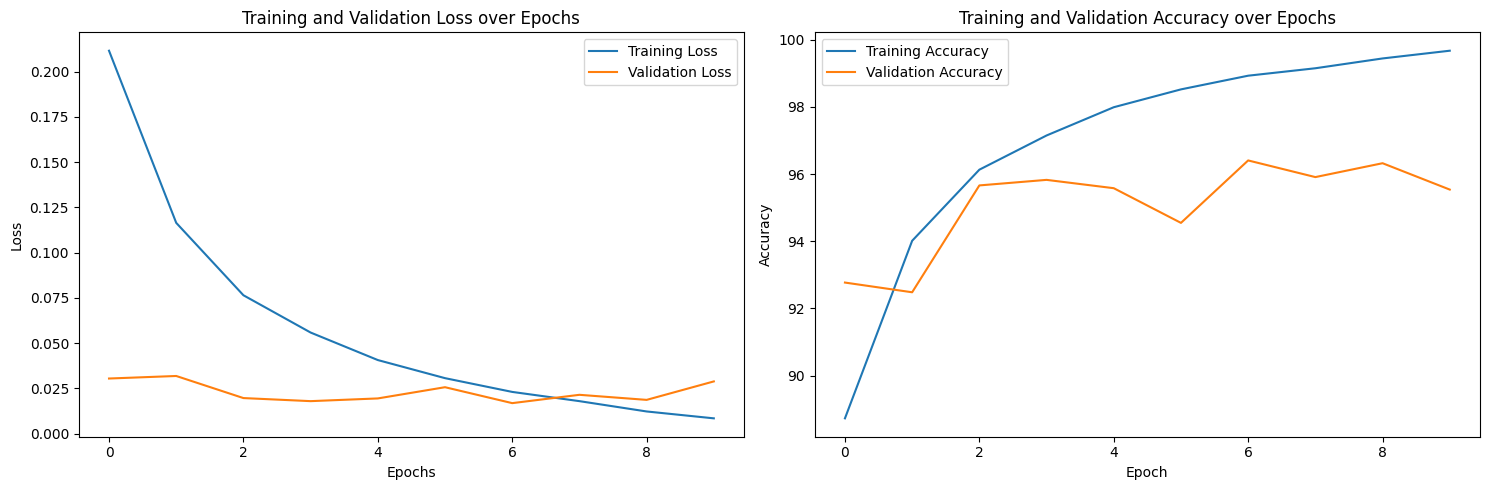

In [52]:
fig,axs = plt.subplots(nrows=1,ncols=2,figsize=(15,5))

axs[0].plot(total_loss_train_plot,label='Training Loss')
axs[0].plot(total_loss_validation_plot,label='Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()


axs[1].plot(total_acc_train_plot,label='Training Accuracy')
axs[1].plot(total_acc_validation_plot,label='Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.tight_layout()

plt.show()


# Inference

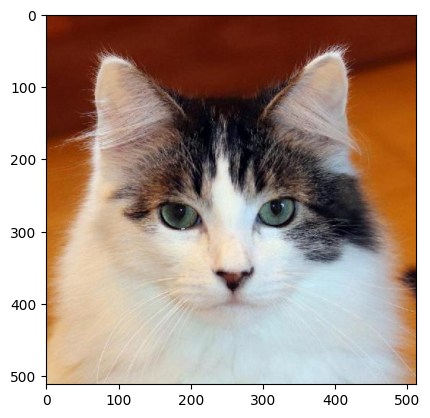


Prediction: 



array(['cat'], dtype=object)

In [55]:
# 1-read image
# 2 - Transform using transform object
# 3- predict through the model
# 4- Inverse transform by label encoder


def predict_image(image_path):
    image = Image.open(image_path).convert('RGB')
    image = transform(image).to(device)

    output = model(image.unsqueeze(0))
    output = torch.argmax(output,axis=1).item()

    return label_encoder.inverse_transform([output])


image = Image.open("/Users/macbook/coding/jupyter notebooks/animal-faces/afhq/val/cat/flickr_cat_000008.jpg")
plt.imshow(image)
plt.show()


print()
print("Prediction: \n")
predict_image("/Users/macbook/coding/jupyter notebooks/animal-faces/afhq/val/cat/flickr_cat_000008.jpg")